In [1]:
# Import
import os
import pandas as pd
import numpy as np

from pathlib import Path

from CellPacking.tissuegeneration import sheet_init, symetric_circular
from CellPacking.dynamics import (Compression, 
                                  AnisotropicLineTension, 
                                  ShearPlanarGeometry, 
                                  PlaneBarrierElasticity)

from tyssue import Sheet
from tyssue import PlanarGeometry
from tyssue.solvers import QSSolver
from tyssue.solvers.viscous import EulerSolver
from tyssue.behaviors.event_manager import EventManager
from tyssue.behaviors.sheet.basic_events import reconnect, reconnect_3D
from tyssue.dynamics import model_factory, effectors
from tyssue.core.history import HistoryHdf5 


import matplotlib.pyplot as plt
from tyssue.draw import sheet_view
from CellPacking.plot import superimpose_sheet_view
from CellPacking.plot import sheet_view as ply_sheet_view

from tyssue.generation import extrude 
from tyssue import Monolayer
from CellPacking.dynamics import ShearMonolayerGeometry
from tyssue.io.hdf5 import save_datasets

from tyssue.io.hdf5 import load_datasets
from tyssue.io.meshes import save_triangular_mesh

CGAL-based mesh generation utilities not found, you may need to install CGAL and build from source
C++ extensions are not available for this version
collision solver could not be imported You may need to install CGAL and re-install tyssue


In [2]:
SIM_DIR = Path('/mnt/sda1/Sophie/1-CellPacking/0-Simulations-to-sort/20241001_3D_QS_without_HI_ElasticityArea')
sim_save_dir = SIM_DIR
try:
    os.mkdir(sim_save_dir)
except FileExistsError:
    pass

In [3]:
%pdb

Automatic pdb calling has been turned ON


# Apical sheet init

In [4]:
def tissue_init(phi, noise):
    
    apical_sheet, border = symetric_circular(10, -100, phi, 0,  noise=noise)

    apical_sheet.face_df['prefered_perimeter'] = 3 * np.sqrt(apical_sheet.face_df['prefered_area'])

    ## apical surface at the equilibrium
    # Solver
    solver_qs = QSSolver(with_t1=False, with_t3=False, with_collisions=False)

    manager = EventManager()
    manager.append(reconnect)
    # Model
    model = model_factory(
        [
            effectors.FaceAreaElasticity,
            effectors.PerimeterElasticity, 
        ])
    for i in range(50):
        manager.execute(apical_sheet)
        res = solver_qs.find_energy_min(apical_sheet, PlanarGeometry, model, periodic=False, options={"gtol": 1e-8})
        if res.success is False:
            print (i, res.success)
        apical_sheet.vert_df[["x", "y"]] += np.random.normal(scale=1e-3, size=(apical_sheet.Nv, 2))
        PlanarGeometry.update_all(apical_sheet)
        manager.update()


    ## Monolayer creation
    apical_sheet.face_df['z'] = 1
    apical_sheet.edge_df['z'] = 1
    apical_sheet.vert_df['z'] = 1

    extruded = extrude(apical_sheet.datasets, method='translation', vector=[0, 0, -2])
    monolayer = Monolayer('mono', extruded)

    monolayer.sanitize(trim_borders=True, order_edges=True)
    monolayer.validate()


    monolayer.face_df['prefered_area'] = monolayer.face_df.loc[0,'prefered_area']
    monolayer.face_df['prefered_perimeter'] = 3*np.sqrt(monolayer.face_df['prefered_area'])
    monolayer.face_df['area_elasticity'] = 1
    monolayer.face_df['perimeter_elasticity'] = 0.5


    

    monolayer.vert_df['barrier_elasticity'] = 280
    monolayer.vert_df['z_barrier'] = 0.6

    monolayer.update_specs({"settings":{"dt":0.01,
                                         'threshold_length': 0.1,
                                         'p_4': 1,
                                         'p_5p': 1,
                                          "nrj_norm_factor": 1.0, 
                                       'multiplier':3, },
                          "cell": {
                                    "x": 0.0,
                                    "y": 0.0,
                                    "z": 0.0,
                                    "is_alive": True,
                                    "prefered_volume": 0.7,
                                    "volume": 0.7,
                                    "volume_elasticity": 0.5,
                                    #P"z_barrier":1.1,
                                    },
                          "edge": {
                                    "dx": 0.0,
                                    "srce": 0,
                                    "face": 0,
                                    "dy": 0.0,
                                    "ny": 0.0,
                                    "nx": 0.0,
                                    "length": 0.0,
                                    "nz": 0.0,
                                    "cell": 0,
                                    "sub_volume": 0.0,
                                    "dz": 0.0,
                                    "sub_area": 0.0,
                                    "trgt": 0},
                          "vert": {
                                    "x": 0.0,
                                    "is_active": True,
                                    "z": 0.0,
                                    "y": 0.0},
                          "face": {
                                    "x": 0.0,
                                    "is_alive": True,
                                    "z": 0.0,
                                    "y": 0.0,}
                        })


    ShearMonolayerGeometry.update_all(monolayer)

    monolayer.face_df['prefered_area'] = monolayer.face_df['area']
    monolayer.face_df['prefered_perimeter'] = 3*np.sqrt(monolayer.face_df['prefered_area'])

    ShearMonolayerGeometry.update_all(monolayer)

    # Manager
    manager = EventManager('face')#, track_event=False)

    monolayer.get_opposite_faces()

    monolayer.get_opposite_faces()
    edge_opp_face = monolayer.upcast_face(monolayer.face_df['opposite'])
    monolayer.edge_df['is_border']=False
    monolayer.edge_df.loc[edge_opp_face[edge_opp_face==-1].index, 'is_border']=True

    monolayer.edge_df['opposite'] = pd.to_numeric(monolayer.edge_df['opposite'])
    monolayer.edge_df['z'] = pd.to_numeric(monolayer.edge_df['z'])

    ShearMonolayerGeometry.update_all(monolayer)

    # monolayer equilibrium before apply forces 
    # Model
    model = model_factory(
        [
#                 PlaneBarrierElasticity,
    #         effectors.LineTension,
            effectors.FaceAreaElasticity,
            effectors.PerimeterElasticity,
            effectors.CellVolumeElasticity,
        ],
    )
    manager.append(reconnect_3D)
    solver_qs = QSSolver(with_t1=False, with_t3=False, with_collisions=False)

    for i in range(10):
        manager.execute(monolayer)

        res = solver_qs.find_energy_min(monolayer, ShearMonolayerGeometry, model, periodic=False, options={"gtol": 1e-8})
        if res.success is False:
            print (i, res.success)
        monolayer.vert_df[["x", "y"]] += np.random.normal(scale=1e-3, size=(monolayer.Nv, 2))
        save_triangular_mesh('monolayer0.19.vtk', monolayer)
        ShearMonolayerGeometry.update_all(monolayer)
        manager.update()


    return monolayer


def simu_process(monolayer_, r, g, ratio):
    
    monolayer=monolayer_.copy(deep_copy=True)
    sim_save_dir = SIM_DIR/str(r)
    try:
        os.mkdir(sim_save_dir)
    except FileExistsError:
        pass
    
    try:
        os.mkdir(sim_save_dir/str(ratio))
    except FileExistsError:
        pass

    gamma_0 = g
    monolayer.update_specs({"edge": {"gamma_0": g}})
    monolayer.edge_df['gamma_0'] = pd.to_numeric(monolayer.edge_df['gamma_0'])
    monolayer.edge_df['gamma_0'] = monolayer.edge_df['gamma_0'].replace(-100, g)
    monolayer.face_df['prefered_perimeter'] = 3*np.sqrt(monolayer.face_df['prefered_area'])
    monolayer.face_df['area_elasticity'] = ratio

    lat_face = monolayer.face_df[monolayer.face_df["segment"]=="lateral"].index
    monolayer.face_df.loc[lat_face, 'prefered_perimeter'] = 3*np.sqrt(monolayer.face_df.loc[lat_face, 'prefered_area'])
    
    monolayer.specs['settings']['file_text'] = os.path.join(sim_save_dir/str(ratio),'output_t1.txt')
    
    # Apply ratio -> prefered perimeter change
    model = model_factory(
        [
#                 PlaneBarrierElasticity,
#             effectors.LineTension,
            effectors.FaceAreaElasticity,
            effectors.PerimeterElasticity,
                effectors.CellVolumeElasticity,
        ],
    )

    solver_qs = QSSolver(with_t1=False, with_t3=False, with_collisions=False)
    # Manager
    manager = EventManager('face')#, track_event=False)
    manager.append(reconnect_3D)

    for i in range(100):
        print('------------TEMPS------------')
        print(i)
        manager.execute(monolayer)
        lat_face = monolayer.face_df[monolayer.face_df["segment"]=="lateral"].index
        monolayer.face_df.loc[lat_face, 'prefered_perimeter'] = ratio*np.sqrt(monolayer.face_df.loc[lat_face, 'prefered_area'])
        res = solver_qs.find_energy_min(monolayer, ShearMonolayerGeometry, model, periodic=False, options={"gtol": 1e-8})
        if res.success is False:
            print (i, res.success)

        monolayer.vert_df[["x", "y"]] += np.random.normal(scale=1e-3, size=(monolayer.Nv, 2))
        manager.update()
        save_datasets(os.path.join(sim_save_dir/str(ratio),'monolayer'+str(i)+'.hf5'), monolayer)
    
    
    ## Apply forces
    # Model

    model = model_factory(
        [
#                 PlaneBarrierElasticity,
            effectors.LineTension,
            effectors.FaceAreaElasticity,
            effectors.PerimeterElasticity,
                effectors.CellVolumeElasticity,
        ],
    )

    solver_qs = QSSolver(with_t1=False, with_t3=False, with_collisions=False)
    # Manager
    manager = EventManager('face')#, track_event=False)
    manager.append(reconnect_3D)

    for i in range(200):
        i=i+100
        print('------------TEMPS------------')
        print(i)
        manager.execute(monolayer)
        lat_face = monolayer.face_df[monolayer.face_df["segment"]=="lateral"].index
        monolayer.face_df.loc[lat_face, 'prefered_perimeter'] = ratio*np.sqrt(monolayer.face_df.loc[lat_face, 'prefered_area'])
        res = solver_qs.find_energy_min(monolayer, ShearMonolayerGeometry, model, periodic=False, options={"gtol": 1e-8})
        if res.success is False:
            print (i, res.success)

        monolayer.vert_df[["x", "y"]] += np.random.normal(scale=1e-3, size=(monolayer.Nv, 2))
        manager.update()
        save_datasets(os.path.join(sim_save_dir/str(ratio),'monolayer'+str(i)+'.hf5'), monolayer)


In [21]:
from joblib import Parallel, delayed
import multiprocessing
from datetime import datetime


global_start=datetime.now()
print ("start : " + str(global_start))
num_cores = multiprocessing.cpu_count()


repeat = np.arange(4)
gammas = 0.2
# ratios = np.arange(0.1, 4.2, 0.2)
ratios = [0.1, 0.5]



# Number of cells in x and y axis
nx = 40
ny = 40
noise = 0.3
phi = np.pi/2

for r in repeat:
    monolayer = tissue_init(phi, noise)
    
    for ratio in ratios :
        try:
            simu_process(monolayer, r, gammas, round(ratio, 1))
        except:
            pass
        
#     results = Parallel(n_jobs=6)(delayed(simu_process)(
#         monolayer, r, gammas,round(ratio,1)) for ratio in ratios)

# simu_process(repeat[0][0], gammas[0][0], phi, noise)
global_end = datetime.now()
print ("end : " + str(global_end))
print ('Duree totale d execution : \n\t\t')
print (global_end-global_start)

start : 2024-10-04 16:40:47.198935
get_opposite_faces
collapse_ edge_ base topology
collapsed
      srce  trgt  face
edge                  
884    378   378   298
885    378   378   309
dropped_two_faces
get_opposite_faces
merge_vertices
collapse_ edge_ base topology
collapsed
      srce  trgt  face
edge                  
1292   370   370   289
1293   370   370   311
dropped_two_faces
get_opposite_faces
merge_vertices


/home/u2175049/anaconda3/lib/python3.11/site-packages/tyssue/core/objects.py:875: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda df: dict(enumerate(df)))
/home/u2175049/anaconda3/lib/python3.11/site-packages/tyssue/core/objects.py:875: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .

get_opposite_faces


/home/u2175049/anaconda3/lib/python3.11/site-packages/tyssue/core/objects.py:875: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda df: dict(enumerate(df)))


2 False
get_opposite_faces


...

/home/u2175049/anaconda3/lib/python3.11/site-packages/tyssue/core/objects.py:875: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda df: dict(enumerate(df)))
/home/u2175049/anaconda3/lib/python3.11/site-packages/tyssue/core/objects.py:875: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .

get_opposite_faces
collapse_ edge_ base topology
collapsed
      srce  trgt  face
edge                  
159      6     6   106
160      6     6   128
dropped_two_faces
get_opposite_faces
merge_vertices
collapse_ edge_ base topology
collapsed
      srce  trgt  face
edge                  
936    115   115    76
dropped_two_faces
get_opposite_faces
merge_vertices


/home/u2175049/anaconda3/lib/python3.11/site-packages/tyssue/core/objects.py:875: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda df: dict(enumerate(df)))
/home/u2175049/anaconda3/lib/python3.11/site-packages/tyssue/core/objects.py:875: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .

get_opposite_faces
collapse_ edge_ base topology
collapsed
      srce  trgt  face
edge                  
1764   500   500   207
1765   500   500   225
dropped_two_faces
get_opposite_faces
merge_vertices


/home/u2175049/anaconda3/lib/python3.11/site-packages/tyssue/core/objects.py:875: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda df: dict(enumerate(df)))
/home/u2175049/anaconda3/lib/python3.11/site-packages/tyssue/core/objects.py:875: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .

In [ ]:
import time
from plyer import notification
notification.notify(
    title = "ALERT!!!",
    message = "It is finish",
    timeout=10
)

In [ ]:
#  raise SystemExit("Stop right there!")


In [ ]:
sfdsfsdfs

# Analyse

In [5]:

result = pd.DataFrame(columns = ['repeat', 'ratio_p', 'nb_change', 'tot_cell'])

ratios = [0.1, 0.5, 1, 5, 10, 50]

repeat=np.arange(4)
for r in repeat:
    sim_save_dir = SIM_DIR/str(r)   
    for ratio in ratios:
        g=round(ratio, 1)
        dir_ = sim_save_dir/str(g)
        try : 
            monolayer_d = load_datasets(os.path.join(sim_save_dir/str(g),'monolayer299.hf5'))
        except: 
            nb_file = len(os.listdir(sim_save_dir/str(g)))
            monolayer_d = load_datasets(os.path.join(sim_save_dir/str(g),'monolayer'+str(nb_file-1)+'.hf5'))
        monolayer = Monolayer("mono", monolayer_d)
        count = len(np.unique(monolayer.edge_df[(monolayer.edge_df['face'].isin(monolayer.face_df[monolayer.face_df['num_sides']==3].index)) &
                  (monolayer.edge_df['segment']=='lateral') & (monolayer.edge_df['face'].isin(monolayer.face_df[monolayer.face_df['area']>0.01].index))]['cell']))
        
        result = pd.concat([result, pd.DataFrame({'repeat':r,
                                                  'ratio_p':g, 
                                                  'nb_change':count,
                                                 'tot_cell': monolayer.Nc},
                          index=[0])],
                          ignore_index=True)
        
        save_triangular_mesh('monolayer'+str(g)+'.vtk', monolayer)
        
result['pourcentage'] = result['nb_change']/result['tot_cell']*100

In [9]:
result.to_csv(os.path.join(SIM_DIR, 'result_pourcentage_min_area.csv'))
result = pd.read_csv(os.path.join(SIM_DIR, 'result_pourcentage_min_area.csv'))


In [6]:
result

,repeat,ratio_p,nb_change,tot_cell,pourcentage
0,0,0.1,0,322,0.0
1,0,0.5,2,327,0.611621
2,0,1.0,20,322,6.21118
3,0,5.0,110,322,34.161491
4,0,10.0,251,322,77.950311
5,0,50.0,272,322,84.47205
6,1,0.1,0,317,0.0
7,1,0.5,4,317,1.26183
8,1,1.0,27,324,8.333333
9,1,5.0,138,324,42.592593


In [7]:
result['pourcentage2'] = result['pourcentage']-np.min(result['pourcentage'])

Text(0.5, 0, 'prefered area')

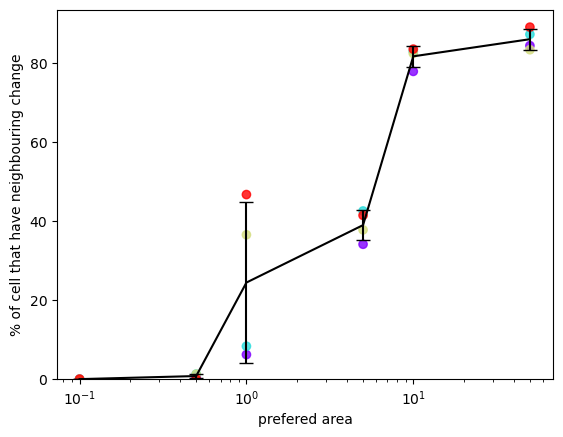

In [8]:
fig, ax = plt.subplots()

ax.scatter(result['ratio_p'], result['pourcentage2'],c=result.repeat, cmap="rainbow", alpha=0.8)
ax.set_xlabel('ratio_p')
ax.set_ylabel('% of cell that have neighbouring change')

ax.plot(result.groupby("ratio_p").mean().index, 
        result.groupby("ratio_p").mean()["pourcentage2"].to_numpy(), 
        c='black')


ax.bar(result.groupby("ratio_p").mean().index, 
       result.groupby("ratio_p").mean().pourcentage2, 
       yerr = result.groupby("ratio_p").std().pourcentage2, 
       align='center',
       alpha=0,
       ecolor='black',
       capsize=5)

ax.set_xscale('log')
ax.set_xlabel("prefered area")
# _=ax.set_yticks([0, 10,20,30, 40])
# _=ax.set_xticks([2,2.5,3.,3.5,4])
# ax.set_xlim(1.9, 4.1)
# ax.set_ylim(-0.5, 45)
# fig.set_size_inches((10,10))
# ax.set_aspect('equal')
# fig.savefig("3d_perimeter_t1.eps", dpi=150)

/tmp/ipykernel_55498/722503648.py:10: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(result.groupby('ratio_p').mean().index,


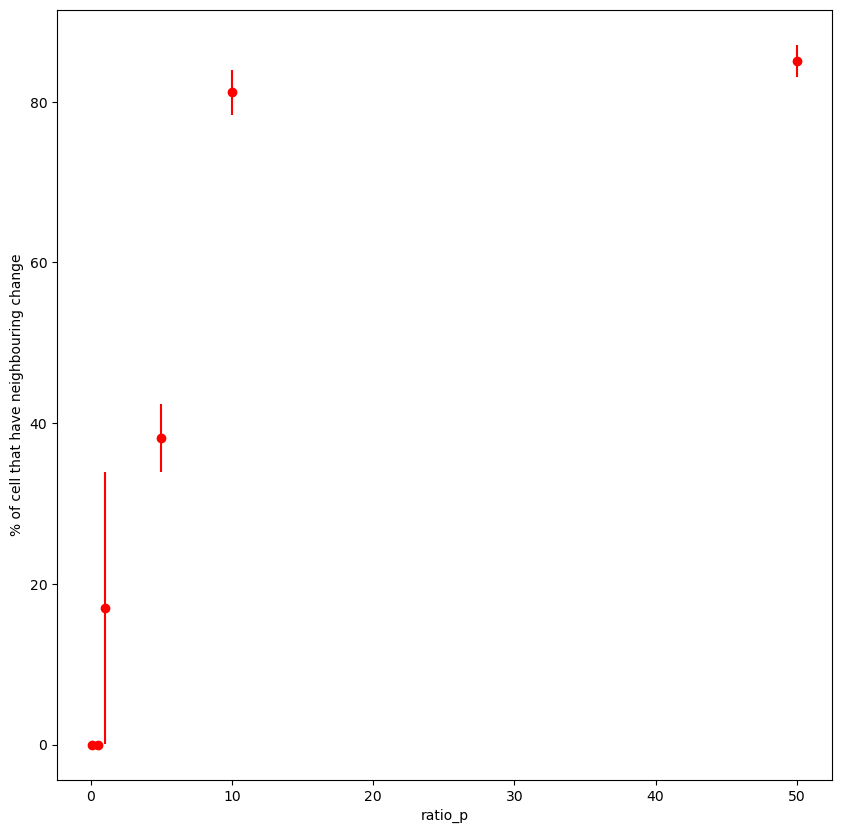

In [19]:
fig, ax = plt.subplots()
# ax.plot(result['gamma'], result['pourcentage'], '.', markersize=10, color='black')
ax.set_xlabel('ratio_p')
ax.set_ylabel('% of cell that have neighbouring change')

ax.plot(result.groupby('ratio_p').mean().index, result.groupby('ratio_p').mean()['pourcentage'], 
        '.',color='red',  markersize=10, label='mean')


ax.errorbar(result.groupby('ratio_p').mean().index,
            result.groupby('ratio_p').mean()['pourcentage'],
            result.groupby('ratio_p').std()['pourcentage'],
            linestyle='None', fmt='-o', color='red')
fig.set_size_inches((10,10))

# fig.savefig(SIM_DIR/'result.eps', dpi=300)

In [ ]:
result.to_csv(os.path.join(SIM_DIR, 'result_count.csv'))

In [ ]:
from tyssue.io.meshes import save_triangular_mesh
save_triangular_mesh('monolayer.vtk', monolayer)

# Result V3 - tenseur 

In [ ]:
from scipy.linalg import eig, inv

result = pd.DataFrame(columns = ['repeat', 'ratio_p', 'T_i', 'eigen'])

repeat = np.arange(3)
ratios = np.arange(2, 4.2, 0.2)

for r in repeat:
    sim_save_dir = SIM_DIR/str(r)   
    for ratio in ratios:
        g=round(ratio, 1)
        dir_ = sim_save_dir/str(g)
        try : 
            monolayer_d = load_datasets(os.path.join(sim_save_dir/str(g),'monolayer299.hf5'))
        except: 
            monolayer_d = load_datasets(os.path.join(sim_save_dir/str(g),'monolayer150.hf5'))
        monolayer = Monolayer("mono", monolayer_d)
        id_new_edges = monolayer.edge_df[(monolayer.edge_df['face'].isin(monolayer.face_df[monolayer.face_df['num_sides']==3].index)) 
                                                 & (monolayer.edge_df['face'].isin(monolayer.face_df[monolayer.face_df['area']>0.01].index))
                                                 &   (((monolayer.edge_df['sz']>0.4) & (monolayer.edge_df['tz']>0.4)) |
                                                     ((monolayer.edge_df['sz']<-0.4) & (monolayer.edge_df['tz']<-0.4))) 
                                                 ].index

        # Pour chaque edge apical (ou basal) d'une face triangulaire
        mm_apical = []
        mm_basal = []
        for id_ in id_new_edges:
            # Recuperation des faces voisines
            id_face_neighbours = monolayer.get_neighbors(monolayer.edge_df.loc[id_]['face'], elem='face')
            neighbouring_face = monolayer.face_df.loc[list(id_face_neighbours)]

            # recuperation des faces uniquement apicale(ou basale)
            faces = []
            segment = ""
            for nf in neighbouring_face.index : 
                if ((monolayer.edge_df[monolayer.edge_df['face']==nf]['sz'] >  0.2).all() & (monolayer.edge_df[monolayer.edge_df['face']==nf]['tz'] >  0.2).all()):
                    if monolayer.face_df.loc[nf]['opposite']==-1:
                        faces.append(nf)
                        segment = "apical"
                elif ((monolayer.edge_df[monolayer.edge_df['face']==nf]['sz'] < -0.2).all() & (monolayer.edge_df[monolayer.edge_df['face']==nf]['tz'] < -0.2).all()):
                    if monolayer.face_df.loc[nf]['opposite']==-1:
                        faces.append(nf)
                        segment = 'basal'

            if len(faces)==2:
                # Creation de la matrice m
                X, Y, Z = monolayer.face_df.loc[faces[0]][list("xyz")] - monolayer.face_df.loc[faces[1]][list("xyz")]


                m = np.array([[X**2,  X*Y , X*Z ],
                              [Y*X  , Y**2, Y*Z ],
                              [Z*X  , Z*Y , Z**2]
                            ])
                m = m[:2,:2]
                if segment == 'apical':
                    mm_apical.append(m)
                elif segment == 'basal':
                    mm_basal.append(m)
                    
        mm_apical = np.array(mm_apical)
        mm_basal  = np.array(mm_basal)
        T_i = mm_apical.shape[0] * mm_apical.mean(axis=0) - mm_basal.shape[0] * mm_basal.mean(axis=0)
        
        
        #Eigen value calculation
        # Diagonalisation
        vals, vecs = eig(T_i)
        diag_m = np.zeros((2, 2))
        for i in range(0,len(vals)):
            diag_m[i,i] = vals[i].real
       
        
        result = pd.concat([result, pd.DataFrame({'repeat':r,
                                                  'ratio_p':g, 
                                                  'T_i':[T_i],
                                                  'eigen':[diag_m]})],
                          ignore_index=True)

In [ ]:
result


In [ ]:
# Plot 
eigen_x = []
eigen_y = []
for i in range(result.shape[0]):
    eigen_x.append(np.min((result.iloc[i]['eigen'][0,0], result.iloc[i]['eigen'][1,1])))
    eigen_y.append(np.max((result.iloc[i]['eigen'][0,0], result.iloc[i]['eigen'][1,1])))
#     eigen_x.append(result.iloc[i]['eigen'][0,0])
#     eigen_y.append(result.iloc[i]['eigen'][1,1])

fig, ax = plt.subplots()
fig.set_size_inches((10,10))
i=0
for g in ratios:
    ax.scatter(eigen_x[i::len(ratios)], eigen_y[i::len(ratios)], s=50, label=round(g, 1))
    i+=1
ax.set_xlabel('eigne_x')
ax.set_ylabel('eigen_y')
ax.legend()

In [ ]:
# Matrice T sommée sur tous les réplicats
result_sum = result.groupby("ratio_p").sum()[['T_i']]/10
result_sum['eigen'] = np.repeat("", result_sum.shape[0])

# Recalcul des valeurs propres sur la somme des T_i (=> Lambda_X(<T_i>))
for id_, val in result_sum.iterrows():
    vals, vecs = eig(val['T_i'])
    diag_m = np.zeros((2,2))
    for i in range(0,len(vals)):
        diag_m[i,i] = vals[i].real
    result_sum.loc[id_]['eigen'] = diag_m

    

# plot
fig, ax = plt.subplots()
fig.set_size_inches((10,10))
for id_, val in result_sum.iterrows():
    ax.scatter(id_, np.min((val['eigen'][0,0], val['eigen'][1,1])), color='black', s=50)

ax.set_xlabel('ratio_p')
ax.set_ylabel('eigen_x')


fig.savefig(SIM_DIR/'gamma_eigenX.png', dpi=150)

In [ ]:
# Bootstrap pour calculer l'intervalle de confiance
eigen_x = []
eigen_y = []
for i in range(result.shape[0]):
    eigen_x.append(np.min((result.iloc[i]['eigen'][0,0], result.iloc[i]['eigen'][1,1])))

from scipy.stats import bootstrap

result_bootstrap = pd.DataFrame(columns= ['ratio_p', 'ci_l', 'ci_h', 'std_error'])
i=0
for g in ratios:
    res = bootstrap((eigen_x[i::21],), 
                    np.std, 
                    confidence_level=0.95, 
                    random_state=1,
                    method="percentile", 
                   )
    
    result_bootstrap = pd.concat([result_bootstrap, 
                                  pd.DataFrame.from_dict({'ratio_p':round(g,2), 
                                                'ci_l':res.confidence_interval[0],
                                                'ci_h':res.confidence_interval[1],
                                                'std_error':res.standard_error,
                                               }, orient='index').T],
                          ignore_index=True)
    i+=1

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches((10,10))
result_bootstrap.plot('ratio_p', ['ci_l', 'ci_h', 'std_error'], ax=ax)
fig.savefig(SIM_DIR/'result_bootstrap.png', dpi=150)

In [ ]:


eigen_x = []
eigen_y = []
for i in range(result_sum.shape[0]):
    eigen_x.append(np.min((result_sum.iloc[i]['eigen'][0,0], result_sum.iloc[i]['eigen'][1,1])))
    eigen_y.append(np.max((result_sum.iloc[i]['eigen'][0,0], result_sum.iloc[i]['eigen'][1,1])))
    
result_sum['Lambda_x'] = eigen_x
result_sum['Lambda_y'] = eigen_y
result_sum

In [ ]:
eigen_x = []
eigen_y = []
for i in range(result.shape[0]):
    eigen_x.append(np.min((result.iloc[i]['eigen'][0,0], result.iloc[i]['eigen'][1,1])))
    eigen_y.append(np.max((result.iloc[i]['eigen'][0,0], result.iloc[i]['eigen'][1,1])))
    
result['Lambda_x'] = eigen_x
result['Lambda_y'] = eigen_y
result

In [ ]:
result.to_csv(SIM_DIR/"result_ti.csv")
result_sum.to_csv(SIM_DIR/"result_t_sum.csv")
result_bootstrap.to_csv(SIM_DIR/"result_bootstrap.csv")